# CitySeg Component-Based Architecture Demo

This notebook demonstrates how to use the CitySeg component-based architecture
introduced in version 0.4.0. It shows both the legacy API for backward compatibility
and the new modular component approach for more flexibility.

## Setup and Imports

In [1]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Import CitySeg
from cityseg.core.config import Config, ModelConfig, VisualizationConfig
from cityseg.components import ImageProcessor, SegmentationProcessor
from cityseg.analysis import VisualizationHandler

# Set paths
# Use relative paths for demo
EXAMPLE_DIR = Path("example_inputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Configuration

First, we'll set up a basic configuration for our image processing pipeline.

In [2]:
example_image = EXAMPLE_DIR / "EustonTap-Screenshot1.png"
example_video = EXAMPLE_DIR / "CaledonianPark1_15s_3840x2160.mov"

# Check if files exist
print(f"Image exists: {example_image.exists()}")
print(f"Video exists: {example_video.exists()}")

# Create a simple configuration
model_config = ModelConfig(
    name="nvidia/segformer-b0-finetuned-cityscapes-1024-1024",
    model_type="segformer",
    device="mps",  # Use "cuda" for GPU if available
    max_size=None,  # Resize to this maximum dimension
    num_workers=0,  # No multiprocessing for demo
)

vis_config = VisualizationConfig(
    alpha=0.7,  # 70% opacity for overlay
    colormap="default",  # Use default colormap for the model
)

config = Config(
    input=example_image,
    output_dir=OUTPUT_DIR,
    output_prefix="demo",
    model=model_config,
    visualization=vis_config,
    frame_step=5,  # Only used for video
    save_raw_segmentation=True,
    save_colored_segmentation=True,
    save_overlay=True,
    analyze_results=True,
    disable_tqdm=False,  # Show progress bars
)

# Print the configuration
print(f"Configuration created for {config.input_type.name}")

Image exists: True
Video exists: True
Configuration created for SINGLE_IMAGE


## Component-Based Approach

The new component-based architecture provides more flexibility and control.

### Image Segmentation with Components

2025-05-07 15:50:13.240 | DEBUG    | cityseg.components.image:load_image:42 - Loaded image from example_inputs/EustonTap-Screenshot1.png: 1833x857


Image loaded: <class 'PIL.Image.Image'>, size: (1833, 857)
Resized to: (1833, 857)


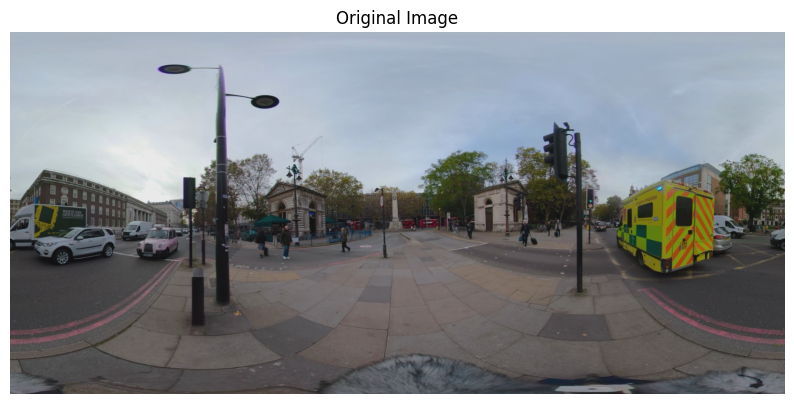

In [3]:
# Load the image
image = ImageProcessor.load_image(example_image)
print(f"Image loaded: {type(image)}, size: {image.size}")

# Resize for processing (keeping aspect ratio)
resized_image = ImageProcessor.resize_image(image, model_config.max_size)
print(f"Resized to: {resized_image.size}")

# Display the image
plt.figure(figsize=(10, 6))
plt.imshow(resized_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

### Create and Apply Segmentation Model

In [11]:
# Create the segmentation pipeline
segmentation_pipeline = SegmentationProcessor.create_pipeline(model_config)
# Process the image
result = SegmentationProcessor.process_image(resized_image, segmentation_pipeline)

# Extract segmentation map and metadata
seg_map = result["seg_map"]
palette = result.get("palette")
id2label = result.get("id2label", {})

print(f"Segmentation map shape: {seg_map.shape}")
print(f"Number of classes in result: {len(id2label)}")

# Show a few class labels as example
sample_labels = list(id2label.items())[:5]
print("Sample class labels:")
for class_id, class_name in sample_labels:
    print(f"  - ID {class_id}: {class_name}")

2025-05-07 16:05:02.957 | DEBUG    | cityseg.components.segmentation:create_pipeline:48 - Creating segmentation pipeline for model: nvidia/segformer-b0-finetuned-cityscapes-1024-1024
2025-05-07 16:05:03.921 | DEBUG    | cityseg.components.segmentation:process_image:66 - Processing single image through segmentation pipeline


Segmentation map shape: (857, 1833)
Number of classes in result: 19
Sample class labels:
  - ID 0: road
  - ID 1: sidewalk
  - ID 2: building
  - ID 3: wall
  - ID 4: fence


In [12]:
result

{'seg_map': array([[10, 10, 10, ..., 10, 10, 10],
        [10, 10, 10, ..., 10, 10, 10],
        [10, 10, 10, ..., 10, 10, 10],
        ...,
        [ 1,  1,  1, ...,  2,  2,  2],
        [ 1,  1,  1, ...,  2,  2,  2],
        [ 1,  1,  1, ...,  2,  2,  2]], dtype=int32),
 'label2id': {'bicycle': 18,
  'building': 2,
  'bus': 15,
  'car': 13,
  'fence': 4,
  'motorcycle': 17,
  'person': 11,
  'pole': 5,
  'rider': 12,
  'road': 0,
  'sidewalk': 1,
  'sky': 10,
  'terrain': 9,
  'traffic light': 6,
  'traffic sign': 7,
  'train': 16,
  'truck': 14,
  'vegetation': 8,
  'wall': 3},
 'id2label': {0: 'road',
  1: 'sidewalk',
  2: 'building',
  3: 'wall',
  4: 'fence',
  5: 'pole',
  6: 'traffic light',
  7: 'traffic sign',
  8: 'vegetation',
  9: 'terrain',
  10: 'sky',
  11: 'person',
  12: 'rider',
  13: 'car',
  14: 'truck',
  15: 'bus',
  16: 'train',
  17: 'motorcycle',
  18: 'bicycle'},
 'palette': array([[128,  64, 128],
        [244,  35, 232],
        [ 70,  70,  70],
        [10

In [5]:
np.arange(1000, 0, -1)  # Example of a numpy operation

array([1000,  999,  998,  997,  996,  995,  994,  993,  992,  991,  990,
        989,  988,  987,  986,  985,  984,  983,  982,  981,  980,  979,
        978,  977,  976,  975,  974,  973,  972,  971,  970,  969,  968,
        967,  966,  965,  964,  963,  962,  961,  960,  959,  958,  957,
        956,  955,  954,  953,  952,  951,  950,  949,  948,  947,  946,
        945,  944,  943,  942,  941,  940,  939,  938,  937,  936,  935,
        934,  933,  932,  931,  930,  929,  928,  927,  926,  925,  924,
        923,  922,  921,  920,  919,  918,  917,  916,  915,  914,  913,
        912,  911,  910,  909,  908,  907,  906,  905,  904,  903,  902,
        901,  900,  899,  898,  897,  896,  895,  894,  893,  892,  891,
        890,  889,  888,  887,  886,  885,  884,  883,  882,  881,  880,
        879,  878,  877,  876,  875,  874,  873,  872,  871,  870,  869,
        868,  867,  866,  865,  864,  863,  862,  861,  860,  859,  858,
        857,  856,  855,  854,  853,  852,  851,  8

In [ ]:
import xarray as xr
import pandas as pd
from datetime import datetime

id2label = segmentation_pipeline.model.config.id2label
label_df = pd.DataFrame.from_dict(id2label, orient="index", columns=["class_label"])
label_df.index.name = "class_id"
# Add a new row for 'void' class
label_df.loc[len(label_df)] = ["void"]

data = xr.Dataset(
    data_vars=dict(
        image=(["y", "x", "rgb"], np.array(resized_image)),
        seg_map=(["y", "x"], np.array(result["seg_map"])),
        palette=(["class_id", "rgb"], np.array(palette)),
        class_label=(["class_id"], label_df["class_label"].values),
    ),
    coords=dict(
        y=np.arange(result["seg_map"].shape[0]),
        x=np.arange(result["seg_map"].shape[1]),
        class_id=pd.Categorical(label_df.index, categories=label_df.index),
    ),
    attrs=dict(
        description="Segmentation map with class labels and palette",
        timestamp=datetime.now().isoformat(),
        **config.to_dict(),
    ),
)

data

ValueError: could not safely cast array from uint8 to int8. While it is not always the case, a common reason for this is that xarray has deemed it safest to encode np.datetime64[ns] or np.timedelta64[ns] values with int64 values representing units of 'nanoseconds'. This is either due to the fact that the times are known to require nanosecond precision for an accurate round trip, or that the times are unknown prior to writing due to being contained in a chunked array. Ways to work around this are either to use a backend that supports writing int64 values, or to manually specify the encoding['units'] and encoding['dtype'] (e.g. 'seconds since 1970-01-01' and np.dtype('int32')) on the time variable(s) such that the times can be serialized in a netCDF3 file (note that depending on the situation, however, this latter option may result in an inaccurate round trip).

In [16]:
data.palette.sel(class_id=data.seg_map)


<xarray.DataArray 'palette' (y: 857, x: 1833, rgb: 3)> Size: 5MB
array([[[ 70, 130, 180],
        [ 70, 130, 180],
        [ 70, 130, 180],
        ...,
        [ 70, 130, 180],
        [ 70, 130, 180],
        [ 70, 130, 180]],

       [[ 70, 130, 180],
        [ 70, 130, 180],
        [ 70, 130, 180],
        ...,
        [ 70, 130, 180],
        [ 70, 130, 180],
        [ 70, 130, 180]],

       [[ 70, 130, 180],
        [ 70, 130, 180],
        [ 70, 130, 180],
        ...,
...
        ...,
        [ 70,  70,  70],
        [ 70,  70,  70],
        [ 70,  70,  70]],

       [[244,  35, 232],
        [244,  35, 232],
        [244,  35, 232],
        ...,
        [ 70,  70,  70],
        [ 70,  70,  70],
        [ 70,  70,  70]],

       [[244,  35, 232],
        [244,  35, 232],
        [244,  35, 232],
        ...,
        [ 70,  70,  70],
        [ 70,  70,  70],
        [ 70,  70,  70]]], dtype=uint8)
Coordinates:
    class_id  (y, x) int64 13MB 10 10 10 10 10 10 10 10 10 ... 2 2 2 2 2 2 2 2 2
  * y         (y) int64 7kB 0 1 2 3 4 5 6 7 ... 849 850 851 852 853 854 855 856
  * x         (x) int64 15kB 0 1 2 3 4 5 6 ... 1827 1828 1829 1830 1831 1832
Dimensions without coordinates: rgb

## Improved xarray Dataset Structure

Let's create a custom xarray accessor for segmentation data to provide specialized methods.

In [ ]:
# Implementation of a custom SegmentationAccessor for xarray
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data.class_label.sel(class_id=data.seg_map)


@xr.register_dataset_accessor("seg")
class SegmentationAccessor:
    """Custom xarray accessor for segmentation datasets.

    This accessor provides specialized methods for working with segmentation data
    stored in xarray Datasets.
    """

    def __init__(self, xarray_obj: xr.Dataset):
        """Initialize the SegmentationAccessor."""
        self._obj = xarray_obj
        self._validate()

    def _validate(self):
        """Validate that this is a proper segmentation dataset"""
        # Basic validation - should have seg_map and class_label at minimum
        required_vars = ["seg_map", "class_label"]
        missing = [var for var in required_vars if var not in self._obj]
        if missing:
            raise ValueError(f"Dataset missing required variables: {missing}")

    def get_class_label_map(self) -> xr.DataArray:
        """Convert numerical classes in seg_map to their text labels"""
        return self._obj.class_label.sel(class_id=self._obj.seg_map)

    def get_colored_segmentation(self) -> xr.DataArray:
        """Convert seg_map to RGB visualization using the palette"""
        return self._obj.palette.sel(class_id=self._obj.seg_map)

    def class_statistics(self) -> dict[str, dict[str, float]]:
        """Calculate statistics for each class in the segmentation map"""
        seg_map = self._obj.seg_map.values
        total_pixels = seg_map.size

        unique_classes, counts = np.unique(seg_map, return_counts=True)

        stats = {}
        for cls_id, count in zip(unique_classes, counts):
            # Get class label if available
            if cls_id < len(self._obj.class_label):
                class_label = self._obj.class_label.sel(class_id=cls_id).item()
            else:
                class_label = f"Unknown-{cls_id}"

            # Calculate statistics
            percentage = 100 * count / total_pixels

            stats[class_label] = {
                "class_id": int(cls_id),
                "pixel_count": int(count),
                "percentage": float(percentage),
            }

        return stats

    def plot(
        self,
        kind: str = "overlay",
        alpha: float = 0.6,
        figsize: tuple[float, float] = (12, 8),
    ) -> None:
        """Plot segmentation results

        Parameters
        ----------
        kind : str
            Type of plot: 'overlay', 'segmentation', 'side-by-side', or 'stats'
        alpha : float
            Transparency for overlay visualization
        figsize : tuple
            Figure size (width, height) in inches
        """
        plt.figure(figsize=figsize)

        if kind == "overlay":
            # Create overlay of segmentation on original image
            plt.imshow(self._obj.image.values)
            colored_seg = self.get_colored_segmentation().values
            plt.imshow(colored_seg, alpha=alpha)
            plt.title("Segmentation Overlay")
            plt.axis("off")

        elif kind == "segmentation":
            # Show just the colored segmentation
            plt.imshow(self.get_colored_segmentation().values)
            plt.title("Segmentation Map")
            plt.axis("off")

        elif kind == "side-by-side":
            # Show original and segmentation side by side
            plt.subplot(1, 2, 1)
            plt.imshow(self._obj.image.values)
            plt.title("Original Image")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(self.get_colored_segmentation().values)
            plt.title("Segmentation Map")
            plt.axis("off")

        elif kind == "stats":
            # Show class percentages as a bar chart
            stats = self.class_statistics()
            # Sort by percentage
            sorted_stats = sorted(
                stats.items(), key=lambda x: x[1]["percentage"], reverse=True
            )

            # Get top 10 classes
            top_classes = sorted_stats[:10]

            labels = [class_name for class_name, _ in top_classes]
            percentages = [stats["percentage"] for _, stats in top_classes]
            colors = []

            # Try to get class colors from palette
            for class_name, class_info in top_classes:
                cls_id = class_info["class_id"]
                if cls_id < len(self._obj.palette) and "palette" in self._obj:
                    # Convert RGB (0-255) to matplotlib format (0-1)
                    rgb = self._obj.palette.sel(class_id=cls_id).values / 255.0
                    colors.append(rgb)
                else:
                    colors.append(None)  # Use default color

            plt.barh(labels, percentages, color=colors)
            plt.xlabel("Area Percentage (%)")
            plt.title("Class Distribution")
            plt.tight_layout()

        else:
            raise ValueError(f"Unknown plot kind: {kind}")

        plt.show()

    def to_binary_mask(self, class_id: int | list[int]) -> np.ndarray:
        """Create a binary mask for the specified class ID(s)

        Parameters
        ----------
        class_id : int or list of int
            Class ID(s) to include in the binary mask

        Returns
        -------
        np.ndarray
            Binary mask where 1 indicates the specified class(es)
        """
        seg_map = self._obj.seg_map.values

        if isinstance(class_id, int):
            return (seg_map == class_id).astype(np.uint8)
        elif isinstance(class_id, (list, tuple)):
            mask = np.zeros_like(seg_map, dtype=np.uint8)
            for cid in class_id:
                mask = np.logical_or(mask, seg_map == cid)
            return mask.astype(np.uint8)
        else:
            raise TypeError("class_id must be an integer or list of integers")

    def get_class_boundaries(
        self, class_id: int | list[int] | None = None
    ) -> np.ndarray:
        """Get the boundaries of segmentation regions

        Parameters
        ----------
        class_id : int or list of int, optional
            If provided, only get boundaries for these classes

        Returns
        -------
        np.ndarray
            Binary boundary mask
        """
        from scipy import ndimage

        if class_id is not None:
            # Get binary mask for specified class(es)
            mask = self.to_binary_mask(class_id)
        else:
            # Use full segmentation map
            mask = self._obj.seg_map.values

        # Apply gradient filter to detect edges
        edges_x = ndimage.sobel(mask, axis=0)
        edges_y = ndimage.sobel(mask, axis=1)
        edges = np.hypot(edges_x, edges_y)

        # Normalize and threshold
        edges = (edges > 0).astype(np.uint8)

        return edges

/var/folders/6t/7h8wn9n92w5f24ml_bkwck9m0000gn/T/ipykernel_16123/1514785452.py:7: AccessorRegistrationWarning: registration of accessor <class '__main__.SegmentationAccessor'> under name 'seg' for type <class 'xarray.core.dataset.Dataset'> is overriding a preexisting attribute with the same name.
  @xr.register_dataset_accessor("seg")


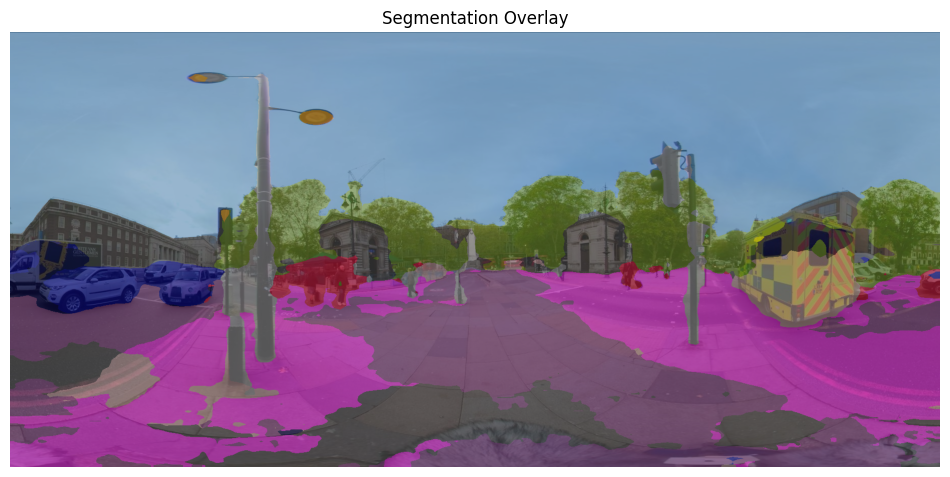

In [18]:
data.seg.plot(kind="overlay", alpha=0.5)

Top 5 classes in the segmentation:
  sky: 38.45% (603928 pixels)
  sidewalk: 16.44% (258316 pixels)
  road: 15.71% (246813 pixels)
  building: 10.68% (167816 pixels)
  vegetation: 8.80% (138178 pixels)


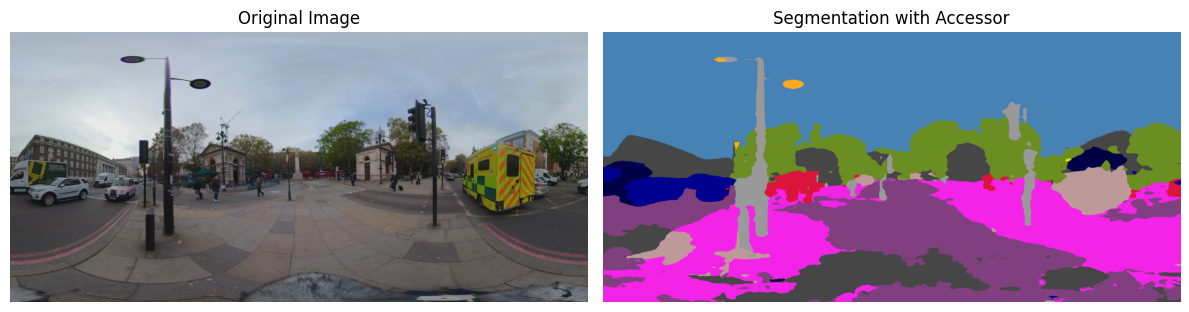

In [17]:
# Let's use our custom SegmentationAccessor to work with the data
# The accessor is available via .seg namespace

# Let's get class statistics
class_stats = data.seg.class_statistics()
top_classes = sorted(
    class_stats.items(), key=lambda x: x[1]["percentage"], reverse=True
)[:5]

print("Top 5 classes in the segmentation:")
for class_name, stats in top_classes:
    print(f"  {class_name}: {stats['percentage']:.2f}% ({stats['pixel_count']} pixels)")

# Generate colored visualization using the accessor
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(data.image.values)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Segmentation with Accessor")
plt.imshow(data.seg.get_colored_segmentation().values)
plt.axis("off")

plt.tight_layout()
plt.show()

### Visualize Segmentation Results

2025-04-25 00:19:24.806 | DEBUG    | cityseg.analysis.visualization:visualize_segmentation:140 - Visualizing segmentation for 1 images
2025-04-25 00:19:24.817 | DEBUG    | cityseg.analysis.visualization:visualize_segmentation:140 - Visualizing segmentation for 1 images


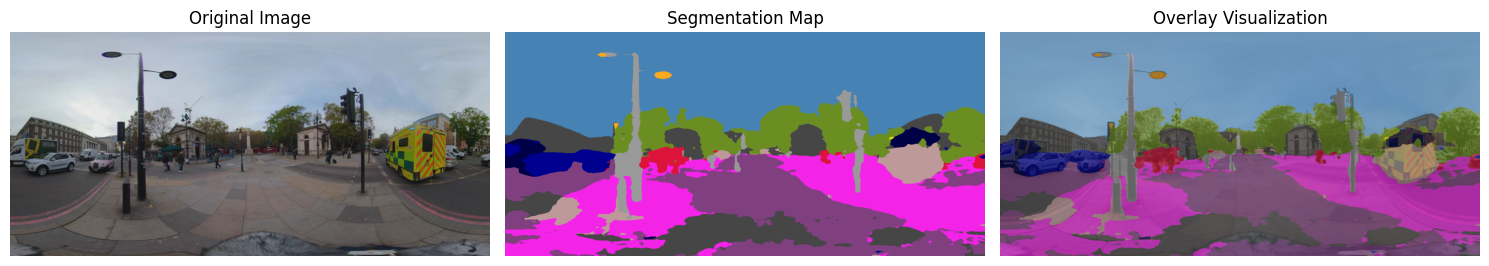

In [6]:
# Create colored segmentation map
colored_segmentation = VisualizationHandler.visualize_segmentation(
    np.array(resized_image), seg_map, palette, colored_only=True
)

# Create overlay visualization
overlay = VisualizationHandler.visualize_segmentation(
    np.array(resized_image), seg_map, palette, colored_only=False, alpha=0.6
)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(resized_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(colored_segmentation)
plt.title("Segmentation Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay Visualization")
plt.axis("off")

plt.tight_layout()
plt.show()

## Save to TileDB

### Analyze Segmentation Results

In [20]:
# Get unique classes and count pixels per class
unique_classes, counts = np.unique(seg_map, return_counts=True)
total_pixels = seg_map.size

# Create a list of class information
class_info = []
for cls_id, count in zip(unique_classes, counts):
    class_name = id2label.get(int(cls_id), f"Unknown-{cls_id}")
    percentage = 100 * count / total_pixels
    class_info.append(
        {
            "id": int(cls_id),
            "name": class_name,
            "pixels": int(count),
            "percentage": float(percentage),
        }
    )

# Sort by percentage (descending)
class_info.sort(key=lambda x: x["percentage"], reverse=True)

# Display analysis
print("Segmentation Analysis:")
for cls in class_info:
    print(
        f"  - {cls['name']} ({cls['id']}): {cls['percentage']:.2f}% ({cls['pixels']} pixels)"
    )

Segmentation Analysis:
  - sky (10): 38.45% (603928 pixels)
  - sidewalk (1): 16.44% (258316 pixels)
  - road (0): 15.71% (246813 pixels)
  - building (2): 10.68% (167816 pixels)
  - vegetation (8): 8.80% (138178 pixels)
  - fence (4): 2.92% (45862 pixels)
  - pole (5): 2.87% (45156 pixels)
  - car (13): 1.69% (26517 pixels)
  - truck (14): 1.23% (19309 pixels)
  - person (11): 1.05% (16551 pixels)
  - traffic light (6): 0.14% (2157 pixels)
  - traffic sign (7): 0.01% (164 pixels)
  - wall (3): 0.01% (114 pixels)


### Save Results

CitySeg provides built-in functionality for saving results, including both visualizations
and structured data storage using Zarr and Parquet.

In [21]:
# 1. Save the visualizations
output_image = OUTPUT_DIR / "demo_original.png"
output_segmentation = OUTPUT_DIR / "demo_segmentation.png"
output_overlay = OUTPUT_DIR / "demo_overlay.png"

Image.fromarray(np.array(resized_image)).save(output_image)
Image.fromarray(colored_segmentation).save(output_segmentation)
Image.fromarray(overlay).save(output_overlay)

print(f"Visualizations saved to {OUTPUT_DIR}:")
print(f"  - Original: {output_image}")
print(f"  - Segmentation: {output_segmentation}")
print(f"  - Overlay: {output_overlay}")

# 2. Save segmentation data and analysis using CitySeg's storage components
from cityseg.analysis import SegmentationAnalyzer  # noqa: E402
import xarray as xr  # noqa: E402

# Create dataset for a single frame (for video, we'd have multiple frames)
# First create a data array with time dimension for consistency
seg_data = xr.DataArray(
    # Add a time dimension for consistency with video format
    np.expand_dims(seg_map, axis=0),
    dims=["time", "y", "x"],
    coords={
        "time": [0],  # Single frame
        "y": np.arange(seg_map.shape[0]),
        "x": np.arange(seg_map.shape[1]),
    },
)

# Create an xarray Dataset with the segmentation data
dataset = xr.Dataset({"segmentation": seg_data})

# Add metadata as attributes
dataset.attrs = {
    "model": model_config.name,
    "model_type": model_config.model_type,
    "frame_step": 1,
    "input_file": str(example_image),
    "original_size": f"{image.width}x{image.height}",
    "id2label": id2label,  # Model's class mapping
}

# Save segmentation data to Zarr and analysis to Parquet using CitySeg's analyzer
zarr_output_path = OUTPUT_DIR / "demo_segmentation"
analysis_output_path = SegmentationAnalyzer.analyze_segmentation_dataset(
    dataset, zarr_output_path
)

print("\nStructured data saved:")
print(f"  - Segmentation data (Zarr): {zarr_output_path}.zarr")
print(f"  - Analysis results (Parquet): {analysis_output_path}")

# Read back the saved analysis data to display some statistics
import pandas as pd  # noqa: E402

analysis_df = pd.read_parquet(analysis_output_path)

print("\nAnalysis summary (top categories by percentage):")
top_categories = analysis_df.sort_values("percentage", ascending=False).head(3)
for _, row in top_categories.iterrows():
    category_id = row["category_id"]
    category_name = id2label.get(category_id, f"Unknown-{category_id}")
    print(
        f"  - {category_name}: {row['percentage']:.2f}% ({row['pixel_count']} pixels)"
    )

2025-04-24 17:17:52.311 | INFO     | cityseg.storage.storage:save_video_analysis:326 - Saved video analysis to outputs/demo_segmentation_analysis.parquet
2025-04-24 17:17:52.312 | INFO     | cityseg.analysis.analyzer:analyze_segmentation_dataset:84 - Segmentation analysis saved to outputs/demo_segmentation_analysis.parquet


Visualizations saved to outputs:
  - Original: outputs/demo_original.png
  - Segmentation: outputs/demo_segmentation.png
  - Overlay: outputs/demo_overlay.png

Structured data saved:
  - Segmentation data (Zarr): outputs/demo_segmentation.zarr
  - Analysis results (Parquet): outputs/demo_segmentation_analysis.parquet

Analysis summary (top categories by percentage):
  - sky: 38.45% (603928.0 pixels)
  - sidewalk: 16.44% (258316.0 pixels)
  - road: 15.71% (246813.0 pixels)


## Video Processing with Components

The component architecture also supports video processing. Here's a basic example
(commented out as execution would take longer).

In [22]:
# Using the video components for frame extraction

from cityseg.components import VideoProcessor  # noqa: E402

# Get video metadata
metadata = VideoProcessor.get_metadata(example_video)
print(f"Video metadata: {metadata}")

# Extract specific frames (e.g., first 3 frames at specified intervals)
frame_indices = [0, 30, 60]
frames = VideoProcessor.get_frames(example_video, frame_indices)
print(f"Extracted {len(frames)} frames")

# Process each frame
processed_frames = []
segmentation_results = []  # Store segmentation results for later analysis
segmentation_maps = []  # Store segmentation maps for dataset creation

for i, frame in enumerate(frames):
    # Resize frame
    resized_frame = ImageProcessor.resize_image(frame, model_config.max_size)

    # Process with segmentation model
    result = SegmentationProcessor.process_image(resized_frame, segmentation_pipeline)

    # Store segmentation results and maps
    result["frame_index"] = frame_indices[i]  # Add frame index for reference
    segmentation_results.append(result)
    segmentation_maps.append(result["seg_map"])

    # Create overlay
    overlay = VisualizationHandler.visualize_segmentation(
        np.array(resized_frame),
        result["seg_map"],
        result.get("palette"),
        colored_only=False,
        alpha=0.6,
    )

    # Save frame
    output_path = OUTPUT_DIR / f"frame_{i}_overlay.png"
    Image.fromarray(overlay).save(output_path)
    processed_frames.append(overlay)

    print(f"Processed frame {i}, saved to {output_path}")

Video metadata: {'frame_count': 450, 'fps': 29.97002997002997, 'width': 3840, 'height': 2160, 'codec': 'h264', 'frame_step': None}


2025-04-24 17:17:53.710 | DEBUG    | cityseg.components.video:get_frames:290 - Extracted 3 frames from example_inputs/CaledonianPark1_15s_3840x2160.mov
2025-04-24 17:17:53.710 | DEBUG    | cityseg.components.segmentation:process_image:66 - Processing single image through segmentation pipeline


Extracted 3 frames


2025-04-24 17:17:55.375 | DEBUG    | cityseg.analysis.visualization:visualize_segmentation:140 - Visualizing segmentation for 1 images
2025-04-24 17:17:58.228 | DEBUG    | cityseg.components.segmentation:process_image:66 - Processing single image through segmentation pipeline


Processed frame 0, saved to outputs/frame_0_overlay.png


2025-04-24 17:17:59.773 | DEBUG    | cityseg.analysis.visualization:visualize_segmentation:140 - Visualizing segmentation for 1 images
2025-04-24 17:18:02.618 | DEBUG    | cityseg.components.segmentation:process_image:66 - Processing single image through segmentation pipeline


Processed frame 1, saved to outputs/frame_1_overlay.png


2025-04-24 17:18:04.107 | DEBUG    | cityseg.analysis.visualization:visualize_segmentation:140 - Visualizing segmentation for 1 images


Processed frame 2, saved to outputs/frame_2_overlay.png


### Analyze and Save Video Segmentation Results

Now we'll analyze the video segmentation results and save them using CitySeg's storage components,
just like we did for the single image above.

2025-04-24 17:37:58.371 | INFO     | cityseg.storage.storage:save_segmentation_data:161 - Saved segmentation data to outputs/video_segmentation.zarr


Stacked segmentation maps shape: (3, 2160, 3840)


2025-04-24 17:37:58.446 | INFO     | cityseg.storage.storage:save_video_analysis:326 - Saved video analysis to outputs/video_segmentation_analysis.parquet
2025-04-24 17:37:58.446 | INFO     | cityseg.analysis.analyzer:analyze_segmentation_dataset:84 - Segmentation analysis saved to outputs/video_segmentation_analysis.parquet



Video segmentation data and analysis saved:
  - Segmentation dataset: outputs/video_segmentation.zarr
  - Analysis results: outputs/video_segmentation_analysis.parquet

Top 5 categories in video frames (by average percentage):
  -     Unknown-8
Name: 4, dtype: object (ID     8
Name: 4, dtype: object): 60.01% average coverage
  -     Unknown-1
Name: 1, dtype: object (ID     1
Name: 1, dtype: object): 24.31% average coverage
  -     Unknown-0
Name: 0, dtype: object (ID     0
Name: 0, dtype: object): 6.86% average coverage
  -     Unknown-9
Name: 5, dtype: object (ID     9
Name: 5, dtype: object): 4.18% average coverage
  -     Unknown-13
Name: 8, dtype: object (ID     13
Name: 8, dtype: object): 2.02% average coverage


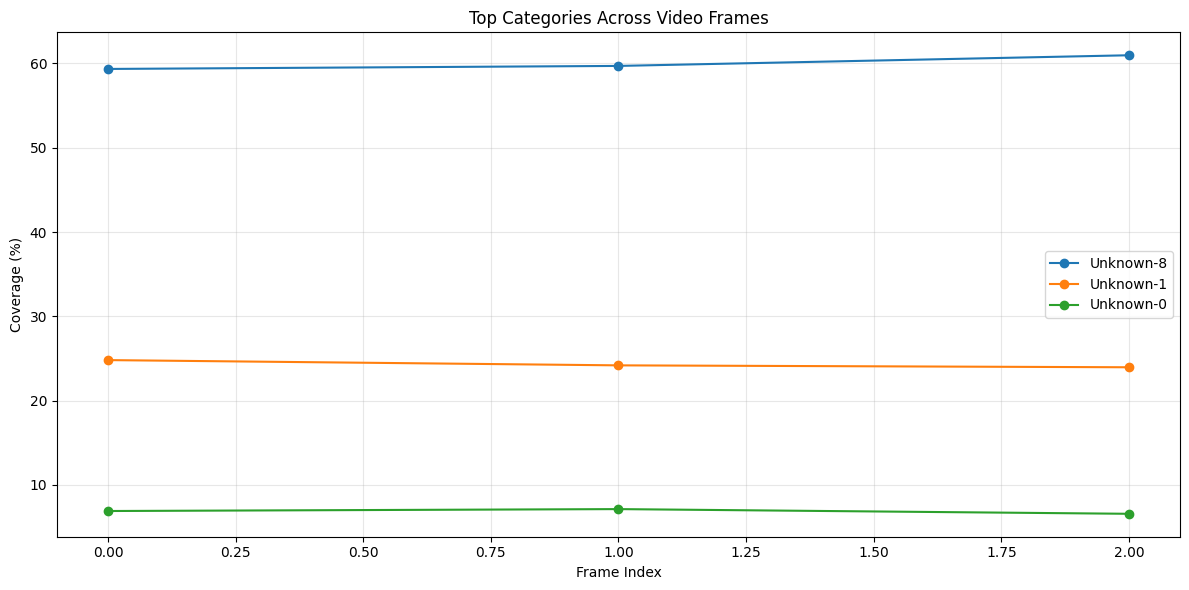

In [42]:
# Create dataset for multiple frames
import xarray as xr  # noqa: E402
from cityseg.analysis import SegmentationAnalyzer  # noqa: E402
from cityseg.storage import ZarrSegmentationStorage, ParquetAnalysisStorage  # noqa: E402

# Stack segmentation maps into a 3D array (time, height, width)
stacked_maps = np.stack(segmentation_maps)
print(f"Stacked segmentation maps shape: {stacked_maps.shape}")

# Create an xarray DataArray with proper dimensions and coordinates
seg_data = xr.DataArray(
    stacked_maps,
    dims=["time", "y", "x"],
    coords={
        "time": frame_indices,  # Use actual frame indices from video
        "y": np.arange(stacked_maps.shape[1]),
        "x": np.arange(stacked_maps.shape[2]),
    },
)

# Create an xarray Dataset with the segmentation data
video_dataset = xr.Dataset({"segmentation": seg_data})

# Extract metadata from the first segmentation result
seg_metadata = SegmentationProcessor.extract_metadata(segmentation_results)

# Add dataset attributes
video_dataset.attrs = {
    "model": model_config.name,
    "model_type": model_config.model_type,
    "frame_step": config.frame_step,  # From the configuration
    "input_file": str(example_video),
    "frame_count": metadata["frame_count"],
    "fps": metadata["fps"],
    "original_size": f"{metadata['width']}x{metadata['height']}",
    "id2label": seg_metadata.get("id2label", {}),
}

# Save segmentation data and analysis
video_output_path = OUTPUT_DIR / "video_segmentation"

# First, explicitly save the dataset to Zarr format
zarr_storage = ZarrSegmentationStorage()
zarr_path = zarr_storage.save_segmentation_data(
    video_dataset, dict(video_dataset.attrs), video_output_path
)

# Then use the SegmentationAnalyzer to analyze and save results to Parquet
video_analysis_path = SegmentationAnalyzer.analyze_segmentation_dataset(
    video_dataset, video_output_path
)

print("\nVideo segmentation data and analysis saved:")
print(f"  - Segmentation dataset: {zarr_path}")
print(f"  - Analysis results: {video_analysis_path}")

# Load and display analysis results
import pandas as pd  # noqa: E402

video_analysis_df = pd.read_parquet(video_analysis_path)

# Group by category to see distribution across all frames
category_summary = (
    video_analysis_df.groupby("category_id")
    .agg({"percentage": ["mean", "std", "min", "max"], "pixel_count": ["mean", "sum"]})
    .reset_index()
)

# Add category names
id2label = video_dataset.attrs.get("id2label", {})
category_summary["category_name"] = category_summary["category_id"].map(
    lambda x: id2label.get(x, f"Unknown-{x}")
)

# Display top categories by mean percentage
print("\nTop 5 categories in video frames (by average percentage):")
top_cats = category_summary.sort_values([("percentage", "mean")], ascending=False).head(
    5
)
for _, row in top_cats.iterrows():
    cat_id = row["category_id"]
    cat_name = row["category_name"]
    mean_pct = row[("percentage", "mean")]
    print(f"  - {cat_name} (ID {cat_id}): {mean_pct:.2f}% average coverage")

# Optional: Create a visualization of category distribution across frames
if len(frame_indices) > 1:  # Only if we have multiple frames
    plt.figure(figsize=(12, 6))

    # Get top categories for plot
    top_category_ids = top_cats["category_id"].values[:3]  # Top 3 for clarity

    # Plot percentage for each frame for top categories
    for cat_id in top_category_ids:
        cat_data = video_analysis_df[video_analysis_df["category_id"] == cat_id]
        cat_name = id2label.get(cat_id, f"Unknown-{cat_id}")
        plt.plot(cat_data["frame_idx"], cat_data["percentage"], "o-", label=cat_name)

    plt.xlabel("Frame Index")
    plt.ylabel("Coverage (%)")
    plt.title("Top Categories Across Video Frames")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## TileDB Storage

In [45]:
video_dataset.attrs["id2label"] = tuple(video_dataset.attrs["id2label"].values())
video_dataset

<xarray.Dataset> Size: 100MB
Dimensions:       (time: 3, y: 2160, x: 3840)
Coordinates:
  * time          (time) int64 24B 0 30 60
  * y             (y) int64 17kB 0 1 2 3 4 5 6 ... 2154 2155 2156 2157 2158 2159
  * x             (x) int64 31kB 0 1 2 3 4 5 6 ... 3834 3835 3836 3837 3838 3839
Data variables:
    segmentation  (time, y, x) int32 100MB 8 8 8 8 8 8 8 8 8 ... 0 0 0 0 0 0 0 0
Attributes:
    model:          nvidia/segformer-b0-finetuned-cityscapes-1024-1024
    model_type:     segformer
    frame_step:     5
    input_file:     example_inputs/CaledonianPark1_15s_3840x2160.mov
    frame_count:    450
    fps:            29.97002997002997
    original_size:  3840x2160
    id2label:       ('road', 'sidewalk', 'building', 'wall', 'fence', 'pole',...

In [47]:
video_dataset.to_netcdf(OUTPUT_DIR.joinpath("video_segmentation.h5").as_posix())

KeyError: ('U', 52)

## Lance Storage for Segmentation Data

CitySeg now supports Lance format for storing segmentation data. Lance provides efficient tensor storage,
built-in versioning, and fast random access to individual frames.

In [13]:
# Save video segmentation data to Lance format
from cityseg.storage import LanceSegmentationStorage  # noqa: E402

# Initialize Lance storage adapter
lance_storage = LanceSegmentationStorage()

# Create a Lance output path
lance_output_path = OUTPUT_DIR / "video_segmentation_lance"

# Save using Lance format (this creates .lance file)
lance_path = lance_storage.save_segmentation_data(
    video_dataset, dict(video_dataset.attrs), lance_output_path
)
print(f"Saved video segmentation data to Lance format: {lance_path}")

# Load the data back from Lance to demonstrate retrieval
loaded_dataset, metadata = lance_storage.load_segmentation_data(lance_path)
print(f"Loaded dataset from Lance with shape: {loaded_dataset.segmentation.shape}")

# Check that we have the same data
print(
    f"Original and loaded datasets identical: {np.array_equal(video_dataset.segmentation.values, loaded_dataset.segmentation.values)}"
)

# Demonstrate loading a specific batch/slice of frames
batch = lance_storage.load_segmentation_batch(lance_path, 0, 2)
print(f"Loaded batch of frames with shape: {batch.segmentation.shape}")

# Get version information (Lance supports versioning)
versions = lance_storage.get_versions(lance_path)
print(f"\nLance dataset versions:\n{versions}")

# Demonstrate updating the dataset with a new version
# For demo purposes, we'll save the same data again, which creates a new version
lance_path_v2 = lance_storage.save_segmentation_data(
    video_dataset, dict(video_dataset.attrs), lance_output_path
)
versions = lance_storage.get_versions(lance_path_v2)
print(f"\nUpdated Lance dataset versions:\n{versions}")

ImportError: cannot import name 'LanceSegmentationStorage' from 'cityseg.storage' (/Users/mitch/Documents/GitHub/cityseg/src/cityseg/storage/__init__.py)

### Why Use Lance for Segmentation Maps?

Lance offers several advantages for storing segmentation data:

1. **Native Tensor Support**: Lance efficiently stores multidimensional tensor data
2. **Versioning**: Built-in versioning tracks changes to your segmentation maps over time
3. **Efficient Random Access**: Fast access to individual frames without loading entire dataset
4. **Columnar Storage**: Optimized for analytical queries on metadata
5. **Compression**: Good compression options for large datasets

Lance is particularly useful for ML workflows where you need to track versions of your data
or access random frames efficiently.

In [ ]:
# Demonstrate querying Lance data
# Get a specific version of the dataset
if len(versions) > 1:
    # Get the first version of the dataset
    first_version = lance_storage.get_version(lance_path, version=0)
    print(
        f"Loaded first version of dataset with shape: {first_version.segmentation.shape}"
    )

    # Compare with current version
    current_version = lance_storage.get_version(lance_path)
    print(f"Current version number: {current_version.attrs.get('lance_version')}")

# Performance comparison between Lance and Zarr (loading frames)
import time

# Time loading from Lance
start = time.time()
_ = lance_storage.load_segmentation_batch(lance_path, 0, 1)
lance_time = time.time() - start

# Time loading from Zarr
zarr_storage = ZarrSegmentationStorage()
start = time.time()
_ = zarr_storage.load_segmentation_batch(zarr_path, 0, 1)
zarr_time = time.time() - start

print(f"\nPerformance comparison (loading single frame):")
print(f"  - Lance: {lance_time:.6f} seconds")
print(f"  - Zarr:  {zarr_time:.6f} seconds")

## Conclusion

The new component-based architecture in CitySeg 0.4.0 provides:

- More granular control over each step of the pipeline
- Better separation of concerns between components
- Flexible composition of components for custom workflows
- Backward compatibility through the legacy interface

While maintaining all the functionality of the original CitySeg library.